In [1]:
# imports
import pandas as pd
import pingouin as pg
import itertools

In [2]:
# read in similarity survey
df = pd.read_csv('similarity-survey.csv')

In [3]:
# rename df columns to make them unique
new_column_names = ['rater']
for i in range(1, 5):
    for j in range(1, 3):
        new_column_names.append(f'dataset{i}_example{j}_independent_variables')
        new_column_names.append(f'dataset{i}_example{j}_control_variables')
        new_column_names.append(f'dataset{i}_example{j}_response_variables')
        new_column_names.append(f'dataset{i}_example{j}_model_info')
        new_column_names.append(f'dataset{i}_example{j}_conclusion')

df.columns = new_column_names

In [4]:
# make the values for columns 1 and on just the first character of the string
for column in df.columns:
    if column == 'rater':
        continue
    df[column] = df[column].apply(lambda x: x[0] if pd.notna(x) else x)
    df[column] = df[column].astype(int)

In [5]:
# make df index the rater column
df = df.set_index('rater')

In [6]:
# get pearson correlations for each pair of raters
pairwise_pearsons = []
for r1, r2 in itertools.combinations(df.index, 2):
    corr = df.loc[r1].corr(df.loc[r2])
    pairwise_pearsons.append({
        'rater1': r1,
        'rater2': r2,
        'pearson_correlation': corr
    })
pairwise_pearson_df = pd.DataFrame(pairwise_pearsons)
print(pairwise_pearson_df.to_markdown(index=False))

| rater1               | rater2               |   pearson_correlation |
|:---------------------|:---------------------|----------------------:|
| Chandan              | LLM Judge Answer Key |              0.569514 |
| Chandan              | Chenglong            |              0.737513 |
| Chandan              | Hao Huang            |              0.760032 |
| LLM Judge Answer Key | Chenglong            |              0.528996 |
| LLM Judge Answer Key | Hao Huang            |              0.709382 |
| Chenglong            | Hao Huang            |              0.717656 |


In [7]:
# now get the pairwise correlation coefficients per category
# (independent variables, control variables, response variables, model info,
# conclusion)

indep_var_cols = [col for col in df.columns if 'independent_variables' in col]
control_var_cols = [col for col in df.columns if 'control_variables' in col]
response_var_cols = [col for col in df.columns if 'response_variables' in col]
model_info_cols = [col for col in df.columns if 'model_info' in col]
conclusion_cols = [col for col in df.columns if 'conclusion' in col]

indep_df = df[indep_var_cols]
control_df = df[control_var_cols]
response_df = df[response_var_cols]
model_info_df = df[model_info_cols]
conclusion_df = df[conclusion_cols]

indep_corrs = []
control_corrs = []
response_corrs = []
model_info_corrs = []
conclusion_corrs = []

for r1, r2 in itertools.combinations(df.index, 2):
    indep_corr = indep_df.loc[r1].corr(indep_df.loc[r2])
    control_corr = control_df.loc[r1].corr(control_df.loc[r2])
    response_corr = response_df.loc[r1].corr(response_df.loc[r2])
    model_info_corr = model_info_df.loc[r1].corr(model_info_df.loc[r2])
    conclusion_corr = conclusion_df.loc[r1].corr(conclusion_df.loc[r2])
    
    indep_corrs.append({
        'rater1': r1,
        'rater2': r2,
        'pearson_correlation': indep_corr
    })
    control_corrs.append({
        'rater1': r1,
        'rater2': r2,
        'pearson_correlation': control_corr
    })
    response_corrs.append({
        'rater1': r1,
        'rater2': r2,
        'pearson_correlation': response_corr
    })
    model_info_corrs.append({
        'rater1': r1,
        'rater2': r2,
        'pearson_correlation': model_info_corr
    })
    conclusion_corrs.append({
        'rater1': r1,
        'rater2': r2,
        'pearson_correlation': conclusion_corr
    })

In [8]:
print("\nIndependent Variables Correlations:")
print(pd.DataFrame(indep_corrs).to_markdown(index=False))
print("\nControl Variables Correlations:")
print(pd.DataFrame(control_corrs).to_markdown(index=False))
print("\nResponse Variables Correlations:")
print(pd.DataFrame(response_corrs).to_markdown(index=False))
print("\nModel Info Correlations:")
print(pd.DataFrame(model_info_corrs).to_markdown(index=False))
print("\nConclusion Correlations:")
print(pd.DataFrame(conclusion_corrs).to_markdown(index=False))


Independent Variables Correlations:
| rater1               | rater2               |   pearson_correlation |
|:---------------------|:---------------------|----------------------:|
| Chandan              | LLM Judge Answer Key |              0.263635 |
| Chandan              | Chenglong            |              0.926367 |
| Chandan              | Hao Huang            |              0.60645  |
| LLM Judge Answer Key | Chenglong            |              0.447214 |
| LLM Judge Answer Key | Hao Huang            |              0.29277  |
| Chenglong            | Hao Huang            |              0.654654 |

Control Variables Correlations:
| rater1               | rater2               |   pearson_correlation |
|:---------------------|:---------------------|----------------------:|
| Chandan              | LLM Judge Answer Key |              0.436436 |
| Chandan              | Chenglong            |              0.467707 |
| Chandan              | Hao Huang            |              0.853

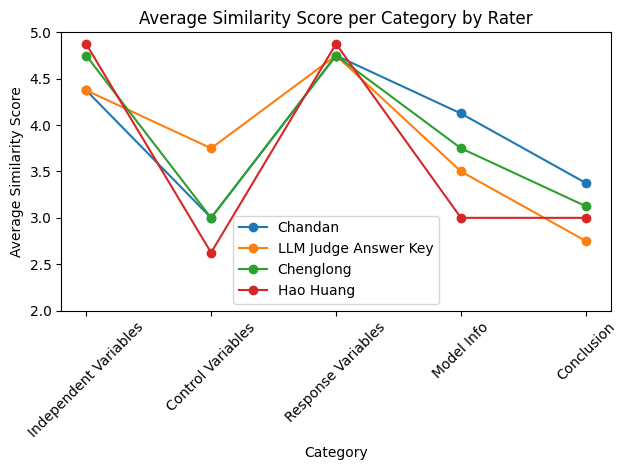

In [9]:
# plot average similarity score per category for each rater, and the grouped "non-LLM" raters
import matplotlib.pyplot as plt
categories = ['Independent Variables', 'Control Variables', 'Response Variables', 'Model Info', 'Conclusion']
category_dfs = [indep_df, control_df, response_df, model_info_df, conclusion_df]
average_scores = {rater: [] for rater in df.index}
for category_df in category_dfs:
    for rater in df.index:
        avg_score = category_df.loc[rater].mean()
        average_scores[rater].append(avg_score)
# plotting
for rater, scores in average_scores.items():
    plt.plot(categories, scores, marker='o', label=rater)
plt.xlabel('Category')
plt.ylabel('Average Similarity Score')
plt.title('Average Similarity Score per Category by Rater')
plt.legend()
plt.xticks(rotation=45)
# make scale of y axis 2 to 5
plt.ylim(2, 5)
plt.tight_layout()
plt.show()